In [1]:
import os
import importlib
import numpy as np, pandas as pd, networkx as nx
import desikan_killiany_atlas as dkatlas
import utils_a3 as utils
import watts_in_adni as nwm

import utils_a1_a3 as utils_a1
import gudhi_persistence_a3 as gp_a1

import matplotlib.pyplot as plt
import lifelines
from sklearn.decomposition import PCA

PATH = os.getcwd()
BASE_DIR = utils.BASE_DIR
print(f"utils base directory: {BASE_DIR}")

utils base directory: C:\Users\sranasin\PycharmProjects\NetworkModels


In [2]:
# reload all
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [3]:
params = {'ngeom_edges_in_persistence': True, 'max_persistence_dim': 2,
               'calculate_representation': True, 'bandwidth': 0.1,
               'resolution': 50, 'num_landscapes': 3,
               'representation_choice_function': 'persistence',
                'non_active': -1,
               'query_filter': None
               }
adni_data_rel_path = os.path.join("resources", "TEST_NEW",
                         "structured_files_UCBERKELEY_AMY_6MM_29Oct2025", "UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv")
graph_file_rel_path = os.path.join("resources", "base_data", "DKATLAS33_base.graphml")

In [6]:
rel_path_base_data = os.path.abspath(os.path.join(BASE_DIR, "resources", "base_data"))
act1, snap1, state1 = utils._pull_saved_patient_data_files(os.path.join(rel_path_base_data, "activation_times.pkl"),
                                                           os.path.join(rel_path_base_data, "snapshots.pkl"),
                                                           os.path.join(rel_path_base_data, "state_values.pkl"))

Pickle file loaded from C:\Users\sranasin\PycharmProjects\NetworkModels\resources\base_data\activation_times.pkl
Pickle file loaded from C:\Users\sranasin\PycharmProjects\NetworkModels\resources\base_data\snapshots.pkl
Pickle file loaded from C:\Users\sranasin\PycharmProjects\NetworkModels\resources\base_data\state_values.pkl


In [69]:
snap_arr = []
state_arr = []

# Let's remove some RID's where there's isn't much progression of the disease
# or cases where disease is already taken place at first scan
for key, values in snap1.items():
    if len(values) <= 2:
        snap_arr.append(key)

for key, values in state1.items():
    if values[0] == 1:
        # print(f"key: {key}, values: {values}")
        state_arr.append(key)
    if sum(values) == 0:
        # print(f"key: {key}, values: {values}")
        state_arr.append(key)

In [75]:
remove_rids = set(snap_arr) | set(state_arr)

query = f"not rid in {list(remove_rids)}"

In [71]:
df_adni = utils.df_rename_to_fsnames(adni_data_rel_path)
df_adni = utils.safe_filter_df(df_adni, filter_all = True)
df_adni.query(expr = 'rid not in @remove_rids', inplace = True)
df_adni.sort_values(by = ['rid', 'scandate'], inplace = True)

df_adni, feature_cols = utils.activations_cortical_regions_df(df_adni, True)
df_adni.head(5)

,loniuid,ptid,rid,scandate,qc_flag,tracer,amyloid_status,amyloid_status_composite_ref,centiloids,summary_suvr,...,lh_transversetemporal_positivity,lh_insula_positivity,lh_thalamus_proper_positivity,lh_caudate_positivity,lh_putamen_positivity,lh_pallidum_positivity,lh_accumbens_area_positivity,lh_hippocampus_positivity,lh_amygdala_positivity,brainstem_positivity
839,1597072,031_S_0618,618,2010-07-19,2,FBP,0.0,0.0,-3.0,0.987,...,1,0,1,1,1,1,0,1,0,1
840,1597042,031_S_0618,618,2012-06-20,2,FBP,0.0,0.0,0.0,1.006,...,0,1,1,0,1,1,0,1,0,1
841,1597012,031_S_0618,618,2015-08-20,2,FBP,0.0,0.0,18.0,1.103,...,1,1,1,1,1,1,0,1,0,1
842,1597027,031_S_0618,618,2018-10-17,2,FBP,1.0,1.0,46.0,1.248,...,1,1,1,1,1,1,0,0,0,1
859,1598498,041_S_0679,679,2011-07-11,2,FBP,0.0,0.0,-16.0,0.917,...,0,0,1,0,0,1,0,0,0,1


### Start Simulation

In [182]:
# reload all
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [183]:
params['query_filter'] = query
results_df, graph = nwm.main_sims(params=params, adni_data_file_path=adni_data_rel_path,
                                  graph_file_path=graph_file_rel_path,
                                  np_global_seed=666, save_files=False)

Patient rid: 618
Patient rid: 679
Patient rid: 1122
Patient rid: 1261
Patient rid: 1280
Patient rid: 2123
Patient rid: 2245
Patient rid: 2263
Patient rid: 2360
Patient rid: 2379
Patient rid: 2392
Patient rid: 4028
Patient rid: 4076
Patient rid: 4119
Patient rid: 4168
Patient rid: 4185
Patient rid: 4254
Patient rid: 4255
Patient rid: 4292
Patient rid: 4350
Patient rid: 4393
Patient rid: 4396
Patient rid: 4428
Patient rid: 4441
Patient rid: 4464
Patient rid: 4513
Patient rid: 4520
Patient rid: 4552
Patient rid: 4576
Patient rid: 4604
Patient rid: 4637
Patient rid: 4653
Patient rid: 4654
Patient rid: 4706
Patient rid: 4767
Patient rid: 4835
Patient rid: 4874
Patient rid: 5097
Patient rid: 5118
Patient rid: 5126
Patient rid: 5140
Patient rid: 5154
Patient rid: 5169
Patient rid: 5178
Patient rid: 5289
Patient rid: 6015
Patient rid: 6080
Patient rid: 6183
Patient rid: 6226
Patient rid: 6256
Patient rid: 6352
Patient rid: 6384
Patient rid: 6437
Patient rid: 6454
Patient rid: 6586


In [184]:
df_temp = results_df
front_columns = ['rid', 'loniuid', 'state', 'scandate', 'time', 'num_active_nodes']

In [185]:
# keep only realizations that have at least one row with state == 1
df_temp = df_temp[df_temp.groupby(['rid'])['state'].transform('max') == 1]
df_temp = df_temp[df_temp.groupby(['rid'])['state'].cumsum() <= 1]

In [186]:

suffix_columns = [f"{prefix}_{i}" for prefix in ['H', 'L', 'I', 'E'] for i in range(3)]
all_columns = list(df_temp.columns)

middle_columns = [col for col in all_columns if col not in front_columns + suffix_columns]
df_temp = df_temp[front_columns + middle_columns + suffix_columns]
df_temp.drop(columns = suffix_columns, inplace=False).head(10)

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes
0,618,1597012,0.0,2015-08-20,0,43,"[1, 5, 6, 8, 9, 11, 12, 13, 14, 15, 20, 22, 31..."
1,618,1597027,1.0,2018-10-17,1,61,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,679,1598473,0.0,2017-07-05,0,41,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
3,679,1598498,0.0,2011-07-11,1,41,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
4,679,1598508,0.0,2013-07-15,2,41,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
5,679,1598553,0.0,2015-07-29,3,42,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
6,679,1598619,1.0,2019-06-03,4,48,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
9,1122,1593391,0.0,2011-03-04,0,19,"[1, 13, 14, 15, 22, 31, 35, 37, 38, 52, 55, 56..."
10,1122,1593451,0.0,2019-06-26,1,19,"[1, 13, 14, 15, 22, 31, 35, 37, 38, 52, 55, 56..."
11,1122,1593459,0.0,2016-01-15,2,22,"[1, 11, 13, 14, 15, 22, 31, 35, 37, 38, 42, 52..."


In [222]:
df = df_temp
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2'], how='left')


In [223]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Explained variance ratio: [1. 1. 1. 1. 1.]
Explained variance ratio: [0.99946388 0.99992777 0.99999277 0.999998   1.        ]
Skipping L_2 — no valid data.
Explained variance ratio: [1. 1. 1. 1. 1.]
Explained variance ratio: [0.39706431 0.65982416 0.90175424 0.95920879 0.98378909]
Skipping I_2 — no valid data.


In [224]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["rid", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["rid"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])


ordered_cols = ["id", "start", "stop", "state", 'H_0', 'H_1', 'H_2'] + landscape_cols + image_cols + essentials_cols
df_pca['id'] = df['rid'].astype(str)  # + "_" + df['realization_id'].astype(str) # + df['time'].astype(str)

df_pca = df_pca[ordered_cols]
df_pca.drop(columns = ['E_0', 'E_1', 'E_2', 'H_2', 'H_0',
                       'L_0_PC1', 'I_0_PC1', 'I_0_PC2', 'I_0_PC3', 'L_1_PC1', 'L_0_PC4', 'L_0_PC5',  'L_1_PC4', 'L_1_PC5', 'I_0_PC4', 'I_0_PC5', 'I_1_PC4', 'I_1_PC5', 'I_1_PC1',
                       'L_0_PC2', 'L_0_PC3', 'L_1_PC2', 'L_1_PC3'
                       ], inplace=True)
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_14376\2663967982.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,H_1,I_1_PC2,I_1_PC3
0,618,0,1.0,0.0,306,-2822.211067,9670.303337
1,618,1,2.0,1.0,532,-2775.996954,9631.987116
2,679,0,1.0,0.0,293,-2545.496616,9165.623611
3,679,1,2.0,0.0,293,-2545.496616,9165.623611
4,679,2,3.0,0.0,293,-2545.496616,9165.623611
5,679,3,4.0,0.0,317,-2523.546732,9119.692444
6,679,4,5.0,1.0,376,-2641.204231,9090.170122
7,NaN,0,1.0,0.0,52,2584.363591,-190.362071
8,NaN,1,2.0,0.0,52,2584.363591,-190.362071
9,1122,2,3.0,0.0,65,2730.234395,-613.940961


### COX

In [225]:
from lifelines import CoxTimeVaryingFitter
ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 191 periods, 41 subjects, 55 events>
         event col = 'state'
number of subjects = 41
 number of periods = 191
  number of events = 55
partial log-likelihood = -155.04
  time fit was run = 2025-11-23 10:02:07 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
H_1        0.01      1.01      0.00            0.00            0.01                1.00                1.01
I_1_PC2    0.00      1.00      0.00           -0.00            0.00                1.00                1.00
I_1_PC3   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
H_1          0.00  5.75 <0.005     26.73
I_1_PC2      0.00  1.29   0.20      2.35
I_1_PC3      0.00 -0.41   0.68      0.56
---
Partial AIC = 316.07
log-likelihood ratio test = 39.89 on 3 df
-log2(p) of ll-ratio test = 26.41

<Axes: xlabel='log(HR) (95% CI)'>

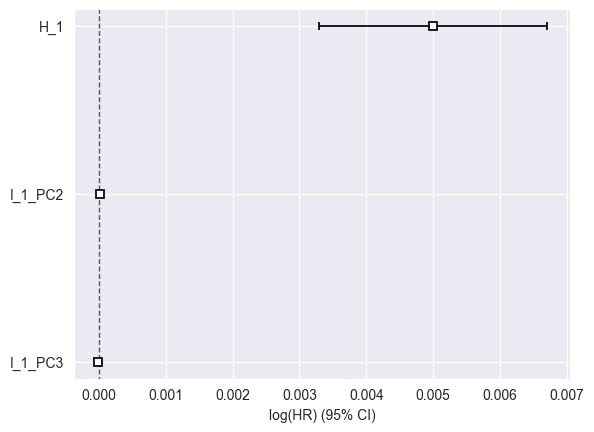

In [226]:
ctv.plot()

### Geometric/Non-Geometric Introduction

In [241]:
graph = nx.read_graphml(os.path.join(utils.BASE_DIR, "resources", "base_data", "DKATLAS33_all.graphml"))
nx.relabel_nodes(graph, lambda x: int(x), copy=False)

In [249]:
print(list(graph.nodes(data=True)[1].keys()))

['dn_correspondence_id', 'region_name']


In [250]:
list(graph.edges(data=True))[0:1][0][2].keys()

dict_keys(['weight1', 'weight2', 'type'])

In [244]:
edge_df = utils.edge_df_from_graph(graph)
type_edges = utils.determine_geom_ngeom_edges(edge_df, fiber_max_geom_length=30)

graph.add_weighted_edges_from(type_edges, weight = 'type')

In [248]:
node_prop_remove = ['dn_position_x', 'dn_position_y', 'dn_position_z', 'dn_region', 'dn_fsname', 'dn_name', 'dn_hemisphere']
edge_prop_remove = ['number_of_fibers', 'FA_mean', 'fiber_length_std', 'fiber_length_mean', 'FA_std']

graph = utils.remove_properties(graph, node_prop_remove, edge_prop_remove)

In [252]:
graph.nodes(data = True)[1]

{'dn_correspondence_id': 1, 'region_name': 'rh_lateralorbitofrontal'}

In [254]:
list(graph.edges(data=True))[0:1]

[(1,
  2,
  {'weight1': 0.35275471181061957,
   'weight2': 0.022105791382886954,
   'type': 'geometric'})]

In [255]:
utils.export_graphml_with_namespace(graph, os.path.join(utils.BASE_DIR, "resources", "base_data", "test_geom_nongeom.graphml"))

GraphML exported to: C:\Users\sranasin\PycharmProjects\NetworkModels\resources\base_data\test_geom_nongeom.graphml


In [257]:
importlib.reload(utils); importlib.reload(nwm); importlib.reload(gp_a1)
importlib.reload(utils_a1); importlib.reload(dkatlas)

<module 'desikan_killiany_atlas' from 'C:\\Users\\sranasin\\PycharmProjects\\NetworkModels\\Project1\\A3\\desikan_killiany_atlas.py'>

In [258]:
params = {'ngeom_edges_in_persistence': False, 'max_persistence_dim': 2,
               'calculate_representation': True, 'bandwidth': 0.1,
               'resolution': 50, 'num_landscapes': 3,
               'representation_choice_function': 'persistence',
                'non_active': -1,
               'query_filter': None
               }

adni_data_rel_path = os.path.join("resources", "TEST_NEW",
                         "structured_files_UCBERKELEY_AMY_6MM_29Oct2025", "UCBERKELEY_AMY_6MM_29Oct2025_suvr.csv")
graph_file_rel_path = os.path.join(utils.BASE_DIR, "resources", "base_data", "test_geom_nongeom.graphml")

##### Find good rids

In [259]:
rel_path_base_data = os.path.abspath(os.path.join(BASE_DIR, "resources", "base_data"))
act1, snap1, state1 = utils._pull_saved_patient_data_files(os.path.join(rel_path_base_data, "activation_times.pkl"),
                                                           os.path.join(rel_path_base_data, "snapshots.pkl"),
                                                           os.path.join(rel_path_base_data, "state_values.pkl"))

snap_arr = []
state_arr = []

# Let's remove some RID's where there's isn't much progression of the disease
# or cases where disease is already taken place at first scan
for key, values in snap1.items():
    if len(values) <= 2:
        snap_arr.append(key)

for key, values in state1.items():
    if values[0] == 1:
        # print(f"key: {key}, values: {values}")
        state_arr.append(key)
        if sum(values) == 0:
        # print(f"key: {key}, values: {values}")
            state_arr.append(key)

remove_rids = set(snap_arr) | set(state_arr)

query = f"not rid in {list(remove_rids)}"
params['query_filter'] = query

Pickle file loaded from C:\Users\sranasin\PycharmProjects\NetworkModels\resources\base_data\activation_times.pkl
Pickle file loaded from C:\Users\sranasin\PycharmProjects\NetworkModels\resources\base_data\snapshots.pkl
Pickle file loaded from C:\Users\sranasin\PycharmProjects\NetworkModels\resources\base_data\state_values.pkl


In [260]:

results_df, graph = nwm.main_sims(params=params, adni_data_file_path=adni_data_rel_path,
                                  graph_file_path=graph_file_rel_path,
                                  np_global_seed=666, save_files=False)

Patient rid: 21
Patient rid: 56
Patient rid: 59
Patient rid: 69
Patient rid: 74
Patient rid: 89
Patient rid: 96
Patient rid: 127
Patient rid: 135
Patient rid: 156
Patient rid: 200
Patient rid: 225
Patient rid: 272
Patient rid: 337
Patient rid: 413
Patient rid: 419
Patient rid: 498
Patient rid: 602
Patient rid: 610
Patient rid: 618
Patient rid: 668
Patient rid: 679
Patient rid: 680
Patient rid: 684
Patient rid: 746
Patient rid: 767
Patient rid: 907
Patient rid: 908
Patient rid: 919
Patient rid: 934
Patient rid: 969
Patient rid: 1045
Patient rid: 1052
Patient rid: 1122
Patient rid: 1155
Patient rid: 1169
Patient rid: 1187
Patient rid: 1261
Patient rid: 1280
Patient rid: 1352
Patient rid: 1418
Patient rid: 2002
Patient rid: 2018
Patient rid: 2036
Patient rid: 2052
Patient rid: 2061
Patient rid: 2072
Patient rid: 2093
Patient rid: 2116
Patient rid: 2123
Patient rid: 2146
Patient rid: 2183
Patient rid: 2187
Patient rid: 2191
Patient rid: 2201
Patient rid: 2220
Patient rid: 2234
Patient rid:

In [261]:
df_temp = results_df
front_columns = ['rid', 'loniuid', 'state', 'scandate', 'time', 'num_active_nodes']

In [262]:
# keep only realizations that have at least one row with state == 1
df_temp = df_temp[df_temp.groupby(['rid'])['state'].transform('max') == 1]
df_temp = df_temp[df_temp.groupby(['rid'])['state'].cumsum() <= 1]

In [263]:

suffix_columns = [f"{prefix}_{i}" for prefix in ['H', 'L', 'I', 'E'] for i in range(3)]
all_columns = list(df_temp.columns)

middle_columns = [col for col in all_columns if col not in front_columns + suffix_columns]
df_temp = df_temp[front_columns + middle_columns + suffix_columns]
df_temp.drop(columns = suffix_columns, inplace=False).head(10)

,rid,loniuid,state,scandate,time,num_active_nodes,active_nodes
76,618,1597012,0.0,2015-08-20,0,43,"[1, 5, 6, 8, 9, 11, 12, 13, 14, 15, 20, 22, 31..."
77,618,1597027,1.0,2018-10-17,1,61,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
81,679,1598473,0.0,2017-07-05,0,41,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
82,679,1598498,0.0,2011-07-11,1,41,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
83,679,1598508,0.0,2013-07-15,2,41,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
84,679,1598553,0.0,2015-07-29,3,42,"[1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 1..."
85,679,1598619,1.0,2019-06-03,4,48,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
123,1122,1593391,0.0,2011-03-04,0,19,"[1, 13, 14, 15, 22, 31, 35, 37, 38, 52, 55, 56..."
124,1122,1593451,0.0,2019-06-26,1,19,"[1, 13, 14, 15, 22, 31, 35, 37, 38, 52, 55, 56..."
125,1122,1593459,0.0,2016-01-15,2,22,"[1, 11, 13, 14, 15, 22, 31, 35, 37, 38, 42, 52..."


In [300]:
df = df_temp
landscape_cols = ['L_0', 'L_1', 'L_2']
image_cols = ['I_0', 'I_1', 'I_2']

n_components = 5

df_pca = df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2']].copy()
# --- FUNCTION TO RUN PCA AND ADD TO df_pca ---
def apply_pca_and_add(df, feature_col, prefix):
    valid_mask = df[feature_col].apply(lambda x: isinstance(x, np.ndarray) and not np.isnan(x).any())
    valid_df = df[valid_mask]
    if valid_df.empty:
        print(f"Skipping {feature_col} — no valid data.")
        return
    X = np.vstack(valid_df[feature_col].values)
    if X.shape[0] == 0:
        print(f"Skipping {feature_col} — empty after stacking.")
        return

    pca = PCA(n_components=min(n_components, X.shape[0]))
    X_pca = pca.fit_transform(X)
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.cumsum()}")

    pca_cols = [f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])]

    temp = valid_df[['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2']].copy()
    temp[pca_cols] = X_pca

    global df_pca
    df_pca = df_pca.merge(temp, on=['rid', 'time', 'state', 'E_0', 'E_1', 'E_2', 'H_0', 'H_1', 'H_2'], how='left')


In [301]:

for col in landscape_cols:
    apply_pca_and_add(df, col, prefix=col)

for col in image_cols:
    apply_pca_and_add(df, col, prefix=col)

Explained variance ratio: [0.82984581 0.94423315 0.97714295 0.98969224 0.99446713]
Explained variance ratio: [0.99946388 0.99992777 0.99999277 0.999998   1.        ]
Skipping L_2 — no valid data.
Explained variance ratio: [0.70454364 0.836423   0.91332622 0.9640371  0.98475322]
Explained variance ratio: [0.41125967 0.66724959 0.90508886 0.95988225 0.98459509]
Skipping I_2 — no valid data.


In [302]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [303]:
landscape_cols = [col for col in df_pca.columns if col.startswith("L_") or col.startswith("I_") or col.startswith("E_")]

df_pca[landscape_cols] = df_pca[landscape_cols].applymap(
    lambda x: np.zeros_like(x) if isinstance(x, float) and np.isnan(x) else x
)
df_pca = df_pca.sort_values(["rid", "time"])

df_pca["start"] = df_pca["time"]
df_pca["stop"] = df_pca.groupby(["rid"])["time"].shift(-1)
df_pca["stop"] = df_pca["stop"].fillna(df_pca["start"] + 1)

landscape_cols = sorted([col for col in df_pca.columns if col.startswith("L_")])
image_cols = sorted([col for col in df_pca.columns if col.startswith("I_")])
essentials_cols = sorted([col for col in df_pca.columns if col.startswith("E_")])



df_pca['id'] = df_pca['rid'] # + "_" + df['realization_id'].astype(str) # + df['time'].astype(str)
ordered_cols = ["id", "start", "stop", "state", 'H_0', 'H_1', 'H_2'] + landscape_cols + image_cols + essentials_cols

df_pca = df_pca[ordered_cols]
df_pca.drop(columns = ['E_0', 'E_1', 'E_2', 'H_2', 'H_0',
                       'L_1_PC1', 'L_1_PC2', 'L_1_PC3',	'L_1_PC4', 	'L_1_PC5',
                       'I_1_PC1', 'I_1_PC2', 'I_1_PC3',	'I_1_PC4', 	'I_1_PC5',
                       'L_0_PC5', 'I_0_PC5'
                       ], inplace=True)
df_pca.head(10)

C:\Users\sranasin\AppData\Local\Temp\ipykernel_14376\2439244949.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pca[landscape_cols] = df_pca[landscape_cols].applymap(


,id,start,stop,state,H_1,L_0_PC1,L_0_PC2,L_0_PC3,L_0_PC4,I_0_PC1,I_0_PC2,I_0_PC3,I_0_PC4
0,618,0,1.0,0.0,163,-0.354091,0.013484,-0.004391,-0.029714,-9.304381,-3.339037,-2.058555,-2.112129
1,618,1,2.0,1.0,270,-0.354091,0.013484,-0.004391,-0.029714,-9.304381,-3.339037,-2.058555,-2.112129
2,679,0,1.0,0.0,154,2.511160,-0.497243,0.132565,-0.052294,67.628388,-6.729495,0.182986,-0.173265
3,679,1,2.0,0.0,154,2.511160,-0.497243,0.132565,-0.052294,67.628388,-6.729495,0.182986,-0.173265
4,679,2,3.0,0.0,154,2.511160,-0.497243,0.132565,-0.052294,67.628388,-6.729495,0.182986,-0.173265
5,679,3,4.0,0.0,170,2.511160,-0.497243,0.132565,-0.052294,67.628388,-6.729495,0.182986,-0.173265
6,679,4,5.0,1.0,190,0.382556,-0.038965,0.851439,0.271733,-8.634674,15.722940,43.066067,-26.694926
7,1122,0,1.0,0.0,26,-0.354091,0.013484,-0.004391,-0.029714,-9.304381,-3.339037,-2.058555,-2.112129
8,1122,1,2.0,0.0,26,-0.354091,0.013484,-0.004391,-0.029714,-9.304381,-3.339037,-2.058555,-2.112129
9,1122,2,3.0,0.0,35,-0.354091,0.013484,-0.004391,-0.029714,-9.304381,-3.339037,-2.058555,-2.112129


In [304]:
from lifelines import CoxTimeVaryingFitter
ctv = CoxTimeVaryingFitter()
ctv.fit(df_pca, id_col="id", start_col="start", stop_col="stop", event_col="state")
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 191 periods, 55 subjects, 55 events>
         event col = 'state'
number of subjects = 55
 number of periods = 191
  number of events = 55
partial log-likelihood = -151.03
  time fit was run = 2025-11-23 19:50:31 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
H_1        0.01      1.01      0.00            0.01            0.01                1.01                1.01
L_0_PC1   18.02  6.71e+07     28.85          -38.52           74.56                0.00            2.40e+32
L_0_PC2   33.53  3.65e+14     45.52          -55.68          122.75                0.00            2.04e+53
L_0_PC3   13.29  5.93e+05     17.73          -21.46           48.05                0.00            7.36e+20
L_0_PC4   11.92  1.51e+05      9.94           -7.55           31.40                0.00            4.35e+13
I_0_PC1   -0.92      0.40      1.30           -3.46            1.63                0.03                5.10
I_0_PC2    0.01      1.01      0.34           -0.65            0.68                0.52                1.97
I_0_PC3   -0.52      0.59      0.59           -1.69            0.64                0.18                1.90
I_0_PC4    0.03      1.03      0.19           -0.35            0.41                0.71                1.51

           cmp to     z      p  -log2(p)
covariate                               
H_1          0.00  6.13 <0.005     30.06
L_0_PC1      0.00  0.62   0.53      0.91
L_0_PC2      0.00  0.74   0.46      1.12
L_0_PC3      0.00  0.75   0.45      1.14
L_0_PC4      0.00  1.20   0.23      2.12
I_0_PC1      0.00 -0.71   0.48      1.06
I_0_PC2      0.00  0.04   0.97      0.04
I_0_PC3      0.00 -0.88   0.38      1.41
I_0_PC4      0.00  0.17   0.86      0.21
---
Partial AIC = 320.06
log-likelihood ratio test = 47.91 on 9 df
-log2(p) of ll-ratio test = 21.84

<Axes: xlabel='log(HR) (95% CI)'>

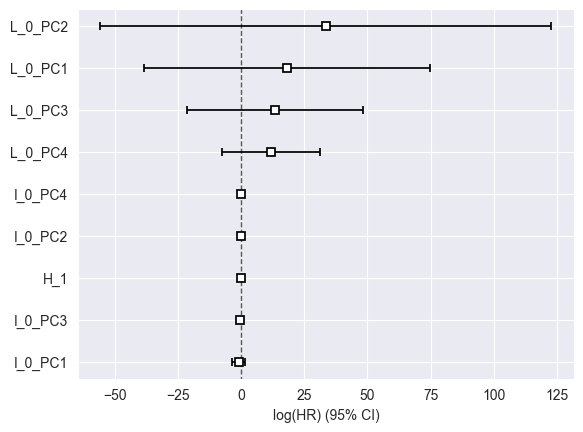

In [305]:
ctv.plot()

In [313]:
import pandas as pd
pc_cols = [c for c in df_pca.columns if 'PC' in c]
n_rows = len(df_pca)
n_patients =df_pca['id'].nunique()
n_events =df_pca['state'].sum()
print(f"rows: {n_rows}, patients and events: {n_patients}, {n_events}")

sds =df_pca[pc_cols].std(ddof=0)
print(f"Across rows variance for PC variables: \n"
      f"{sds.sort_values().head(10)}")

# within-subject variance
within_var =df_pca.groupby('id')[pc_cols].var()
prop_zero_within = (within_var==0).mean()
print(f"Within subject variance: \n"
      f"{prop_zero_within.sort_values()}")

rows: 191, patients and events: 55, 55.0
Across rows variance for PC variables: 
L_0_PC4     0.110093
L_0_PC3     0.178285
L_0_PC2     0.332385
L_0_PC1     0.895263
I_0_PC4     8.083280
I_0_PC3     9.954268
I_0_PC2    13.035433
I_0_PC1    30.129436
dtype: float64
Within subject variance: 
L_0_PC1    0.745455
L_0_PC2    0.745455
L_0_PC3    0.745455
L_0_PC4    0.745455
I_0_PC1    0.763636
I_0_PC2    0.763636
I_0_PC3    0.763636
I_0_PC4    0.763636
dtype: float64
